# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad

# Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [6]:
data = Elias24

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [7]:
# Frank Parameters
N = 300
 # load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

# F2D

In [8]:
plt.figure(figsize=(2, 2))
plt.imshow(u_g)
plt.colorbar()
plt.show()

NameError: name 'u_g' is not defined

<Figure size 200x200 with 0 Axes>

In [ ]:
ud, vd, _ = geom.deproject(u_g, v_g)

In [ ]:
plt.figure(figsize=(2, 2))
plt.imshow(ud)
plt.colorbar()
plt.show()

In [ ]:
vis_shifted_phase_shifted = geom.apply_phase_shift(u_shifted, v_shifted, vis_shifted)

In [ ]:
plt.figure(figsize=(3, 3))
plt.imshow(np.log(np.abs(vis_shifted)))
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted)), 
           extent = [u_shifted_1d[0], u_shifted_1d[-1], v_shifted_1d[-1], v_shifted_1d[0]],
           vmin=-10, vmax=-2
          )
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted)), 
           extent = [ud[0][0], ud[0][-1], vd[-1][0], vd[0][0]], 
           vmin=-10, vmax=-2
          )
plt.title("deprojected")
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted)), 
           extent = [ud_1d[0], ud_1d[-1], vd_1d[-1], vd_1d[0]],
           vmin=-10, vmax=-2
          )
plt.title("deprojected")
plt.colorbar()
plt.show()

In [ ]:
# convention.

In [ ]:
v_shifted_flipped = np.flip(v_shifted, axis = 0)
u_shifted_flipped = np.flip(u_shifted, axis = 1)
vis_shifted_flipped = np.flip(vis_shifted, axis = (0,1))

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted_flipped)), 
           extent = [u_shifted_flipped[0][0], u_shifted_flipped[0][-1], v_shifted_flipped[-1][0], v_shifted_flipped[0][0]], 
           vmin=-10, vmax=-2
          )
plt.colorbar()
plt.show()

In [ ]:
u_shifted_flipped_1d = -u_shifted_1d
v_shifted_flipped_1d = -v_shifted_1d

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.abs(vis_shifted_flipped)), 
           extent = [u_shifted_flipped_1d[0], u_shifted_flipped_1d[-1], v_shifted_flipped_1d[-1], v_shifted_flipped_1d[0]], 
           vmin=-10, vmax=-2
          )
plt.colorbar()
plt.show()

### Run

In [9]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [10]:
frank2d.process_vis(u, v, Vis, Weights)

Shifted grid..
Setting gridded data...


Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 1.01  min |  60.32 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 0.6400694976529923
Final tolerance :  0.6400694976529923
.... iteration:  0
                        -> actual tol:  64006949.76529922 vs  0.6400694976529923
.... iteration:  1
                        -> actual tol:  10063038.671583705 vs  0.6400694976529923
.... iteration:  2
                        -> actual tol:  11634649.891481854 vs  0.6400694976529923
.... iteration:  3
                        -> actual tol:  9701737.250494102 vs  0.6400694976529923
.... iteration:  4
                        -> actual tol:  15340335.617247121 vs  0.6400694976529923
.... iteration:  5
                        -> actual tol:  10968934.337354373 vs  0.6400694976529923
.... iteration:  6
                        -> actual tol:  14164318.005830145 vs  0.6400694976529923
.... iteration:  7
                        -> actual tol:  20

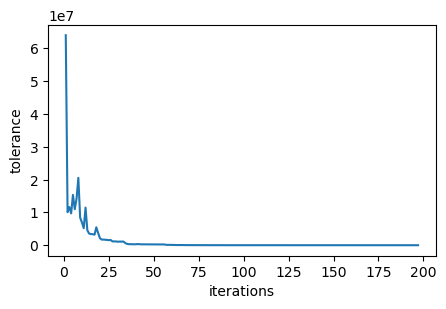

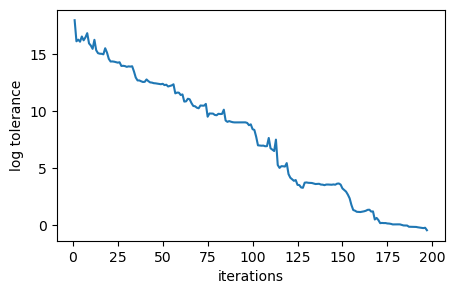

--> time = 0.11  min |  6.44 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...
F2D model in 3.89 minutes.


In [11]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 7e4}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

# Plot

In [12]:
u, v = frank2d.u, frank2d.v
x, y = frank2d.x, frank2d.y
vis = frank2d.visibility_model

u_grid, v_grid = frank2d.u_grid, frank2d.v_grid

#### imshow

In [ ]:
extent_uv_convention = [-u[0], -u[-1], -v[-1], -v[0]]
extent_uv_original = [u[0],  u[-1], v[-1], v[0]]

In [ ]:
plt.figure(figsize=(3, 3))
plt.imshow(np.log(np.abs(frank2d.visibility_model)), 
          extent=extent_uv_convention, cmap="viridis",
               vmin=-10, vmax=-2)
plt.colorbar()

In [ ]:
extent_xy_convention = np.array([-x[0], -x[-1], -y[-1], -y[0]])*rad_to_arcsec
extent_xy_original = np.array([x[0],  x[-1], y[-1], y[0]])*rad_to_arcsec

In [ ]:
int = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis)))/(frank2d._FT._dx * frank2d._FT._dy)
int = int.real

In [ ]:
plt.figure(figsize= (4, 4))

norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.pcolormesh(x,
               y,
               int,
               cmap="magma",
               norm=norm)
plt.xlabel(r'x ["]')
plt.ylabel(r'y ["]')
cmap = plt.colorbar(shrink=0.8)
plt.title("")
cmap.set_label(r'I [Jy/sr]', size=10)

lim = 1.5
# Límites de ejes:
plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import matplotlib.colors as colors
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(int,  extent = extent_xy_convention,
           cmap='magma',norm=norm, origin='upper')
plt.title("convention")
plt.colorbar()


In [ ]:
def deproject_uv(frank2d, u, v):
    inc = frank2d._Geometry._inc*deg_to_rad
    pa = (frank2d._Geometry._pa)*deg_to_rad

    cos_t = np.cos(pa)
    sin_t = np.sin(pa)

    up = u * cos_t - v * sin_t
    vp = u * sin_t + v * cos_t

    up = up * np.cos(inc)

    return up, vp

In [ ]:
ud, vd = deproject_uv(frank2d, u_grid, v_grid)

In [ ]:
plt.figure(figsize=(1, 1))
plt.imshow(-u_grid)
plt.show()

plt.figure(figsize=(1, 1))
plt.imshow(ud)
plt.show()

In [ ]:
plt.figure(figsize= (4, 4))
u, v = ud, vd
plt.pcolormesh(u,
               v,
               np.log(np.abs(vis)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
plt.title("deprojected")
cmap.set_label(r'V [Jy]', size=10)

#u, v = -ud, -vd
# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

##### phase shifting

In [ ]:
u_, v_ = (-u_grid).ravel(order ='C'), (-v_grid).ravel(order ='C')
vis_ = vis.ravel(order ='C')

In [ ]:
vis_shifted_ = geom.apply_phase_shift(u_, v_, vis_).reshape(N, N)

In [ ]:
plt.figure(figsize= (4, 4))
plt.pcolormesh(u_grid,
               v_grid,
               np.log(np.abs(vis_shifted_)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'V [Jy]', size=10)

#u, v = -ud, -vd
# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

In [ ]:
vis_shifted = geom.apply_phase_shift(-u_grid, -v_grid, vis)

In [ ]:
plt.figure(figsize= (4, 4))
u, v = ud, vd
plt.pcolormesh(u,
               v,
               np.log(np.abs(vis_shifted)),
               cmap="viridis",
               vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
plt.title("deprojected")
cmap.set_label(r'V [Jy]', size=10)

#u, v = -ud, -vd
# Límites de ejes:
plt.xlim(u.max(), u.min())
plt.ylim(v.max(), v.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()
plt.show()

In [ ]:
int_shifted = np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(vis_shifted_))).real/(frank2d._FT._dx * frank2d._FT._dy)

In [ ]:
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(int_shifted, cmap='magma',norm=norm)
plt.colorbar()

In [ ]:
plt.figure(figsize=(2, 2))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(np.log(int_shifted - int), cmap='magma',norm=norm)
plt.colorbar()

In [ ]:
plt.figure(figsize=(2, 2))
plt.imshow(np.log(np.abs(vis) -np.abs(vis_shifted)), 
          extent=extent_uv_convention)
plt.colorbar()

#### colormesh

In [ ]:
def deproject_xy(frank2d, x, y):
    inc = frank2d._Geometry._inc*deg_to_rad
    pa = (frank2d._Geometry._pa-90)*deg_to_rad

    cos_i = np.cos(inc)
    cos_pa, sin_pa = np.cos(pa), np.sin(pa)

    x_d = (x * cos_pa + y * sin_pa)
    y_d = (x *-sin_pa + y * cos_pa)

    x_d = x_d/cos_i
    return x_d, y_d

In [ ]:
x, y = frank2d.x_grid, frank2d.y_grid
xd, yd = deproject_xy(frank2d, x, y)

In [ ]:
plt.figure(figsize= (4, 4))

x, y = xd, yd
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.pcolormesh(x,
               y,
               int_shifted,
               cmap="magma",
               norm=norm)
plt.xlabel(r'x ["]')
plt.ylabel(r'y ["]')
cmap = plt.colorbar(shrink=0.8)
plt.title("")
cmap.set_label(r'I [Jy/sr]', size=10)

# Límites de ejes:
plt.xlim(x.max(), x.min())
plt.ylim(y.max(), y.min())

plt.gca().set_aspect(1)
plt.gca().invert_yaxis()
plt.show()

In [13]:
Plot_ = Plot(frank2d, geom)

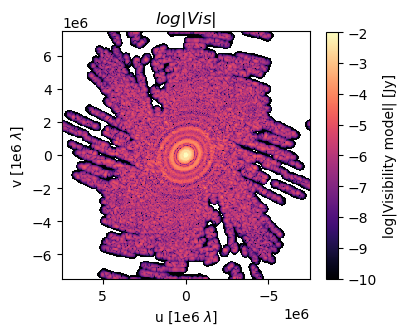

In [14]:
Plot_.visibility(fig_size = 4)

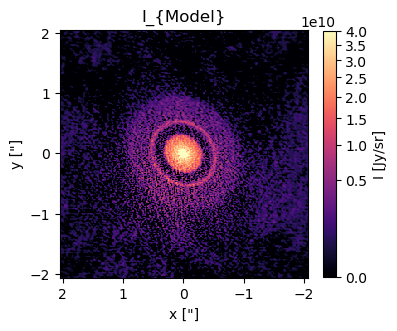

In [15]:
Plot_.intensity(fig_size = 4)

In [21]:
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']

In [22]:
uv_table = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

Performing 1D Frank fit...


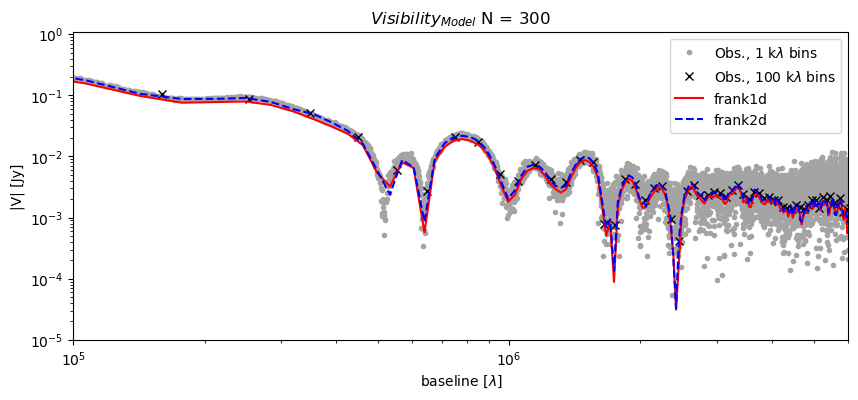

In [23]:
Plot_.visibility_profile(input = uv_table, weighted = True, frank1d = True)

In [24]:
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'
fits_file = dir + disk

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Performing 1D Frank fit...


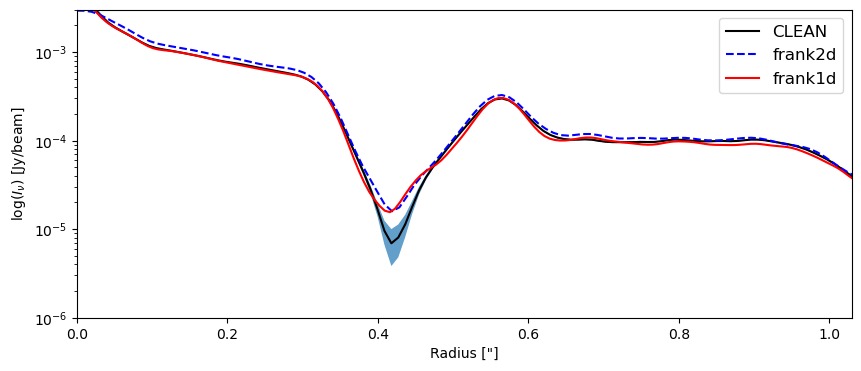

In [25]:
Plot_.intensity_profile(clean = True, fits_file = fits_file)

## Comparing CLEAN image

In [104]:
import matplotlib.colors as colors

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.ndimage import shift as ndshift

### CLEAN

In [208]:
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'

fits_name = dir + disk
fits_image = fits.open(fits_name)

In [209]:
header = fits_image[0].header

In [210]:
w = WCS(header).celestial
img_clean = np.squeeze(fits_image[0].data)

In [211]:
data = img_clean

In [212]:
dX_as, dY_as = dra, ddec

In [322]:
# --- inputs assumed: header, w (astropy WCS), img_clean, dX_as, dY_as,
#                     frank2d, rad_to_arcsec, np, u, SkyCoord, ndshift ---

hdr  = header.copy()
data = img_clean

# --- image center in pixel coordinates ---
ny, nx = data.shape
xc, yc = (nx - 1) / 2.0, (ny - 1) / 2.0

# --- sky coord at current image center (pixel -> world) ---
ra_c, dec_c = w.pixel_to_world_values(xc, yc)
center_sky = SkyCoord(ra_c * u.deg, dec_c * u.deg)

# --- sky coord that SHOULD land at the center after applying the offset ---
target_sky = center_sky.spherical_offsets_by(dX_as * u.arcsec, dY_as * u.arcsec)

# --- where does that target currently fall? (world -> pixel) ---
x1, y1 = w.world_to_pixel(target_sky)

# --- required subpixel shift to bring target to the matrix center ---
dx_pix = xc - x1
dy_pix = yc - y1

# --- shift the image (cubic interpolation) ---
data_shifted = ndshift(data, shift=(dy_pix, dx_pix), order=3, mode="constant", cval=np.nan)

# --- update WCS: shifting +Δpix in the array => decrease CRPIX by -Δpix ---
hdr["CRPIX1"] = hdr["CRPIX1"] + dx_pix
hdr["CRPIX2"] = hdr["CRPIX2"] + dy_pix

# --- pixel grid and world coords for the (shifted) image ---
x_max_arcsec = float(frank2d.x_grid.max() * rad_to_arcsec)  # desired half-size (arcsec)

Xpix, Ypix = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
RA_deg, DEC_deg = w.pixel_to_world_values(Xpix, Ypix)

# Offsets relative to CRVAL (includes cos(dec) factor automatically)
ref_sky = SkyCoord(hdr["CRVAL1"] * u.deg, hdr["CRVAL2"] * u.deg)
grid_sky = SkyCoord(RA_deg * u.deg, DEC_deg * u.deg)
dx, dy = ref_sky.spherical_offsets_to(grid_sky)  # angles on the tangent plane

X_as = dx.to(u.arcsec).value   # +X: East
Y_as = -dy.to(u.arcsec).value   # +Y: North

# --- build a ±R arcsec mask and compute a tight bounding box in pixels ---
R = x_max_arcsec +0.1
mask = (np.abs(X_as) <= R) & (np.abs(Y_as) <= R)
ys, xs = np.where(mask)

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

# --- coherent crops (data and coordinate grids) ---
data_c = data_shifted[y0:y1, x0:x1]
X_as_c = X_as[y0:y1, x0:x1]
Y_as_c = Y_as[y0:y1, x0:x1]

In [323]:
x_max_arcsec

2.0462666666666665

In [324]:
X_as_c.max()

2.1450000002563216

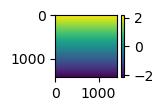

In [325]:
plt.figure(figsize=(1,1))
plt.imshow(Y_as_c)
plt.colorbar(shrink = 0.8)

In [326]:
clean_img = np.flipud(data_c)

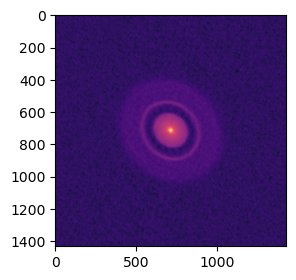

In [327]:
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(clean_img, cmap ='magma', norm=norm)
plt.show()

In [328]:
data_c = np.flipud(data_c)

### Frank2D

In [329]:
x_arcsec, y_arcsec = frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec
extent_convention = [-x_arcsec[0], -x_arcsec[-1], -y_arcsec[-1], -y_arcsec[0]]
model = frank2d.intensity_model

In [330]:
# let's do a phase shift first.
u_ = frank2d.u_grid
v_ = frank2d.v_grid
vis_ = frank2d.visibility_model
vis = geom.apply_phase_shift(-u_, -v_, vis_)
I_shifted = frank2d.transform(vis).real

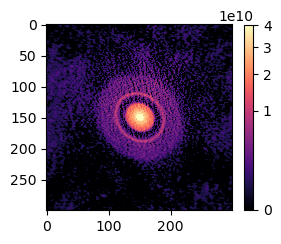

In [331]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(I_shifted, cmap='magma',norm=norm)
plt.colorbar(shrink = 0.8)

In [351]:
X_frank2d = -frank2d.x_grid*rad_to_arcsec
Y_frank2d = -frank2d.y_grid*rad_to_arcsec
M_frank2d = I_shifted

#### Turn into the same grid as CLEAN

In [352]:
index = np.where((u == 0) & (v == 0))
V_00 = vis[index].real
V_00

array([], shape=(0, 300), dtype=float64)

In [353]:
X = X_as_c
Y = Y_as_c
M = data_c

x_ = X[0, :]
y_ = Y[:, 0]

In [354]:
Xs = X_frank2d
Ys = Y_frank2d
Ms = M_frank2d

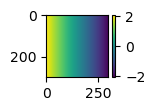

In [355]:
plt.figure(figsize=(1,1))
plt.imshow(X_mod)
plt.colorbar(shrink = 0.8)

In [377]:
import astropy.units as u
from astropy.convolution import convolve_fft, Gaussian2DKernel
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator

# interpolate model CLEAN to the grid of Frank2D

# Method 1
pts_src   = np.c_[Y.ravel(order='C'), X.ravel(order='C')]               # (N,2) en orden (y,x)
vals_src  = M.ravel(order='C')                                     # (N,)
pts_tgt   = np.c_[Ys.ravel(order='C'), Xs.ravel(order='C')]             # (N_tgt,2)

model_1 = griddata(
    pts_src, vals_src, pts_tgt, method='linear', fill_value=np.nan
).reshape(Ms.shape)

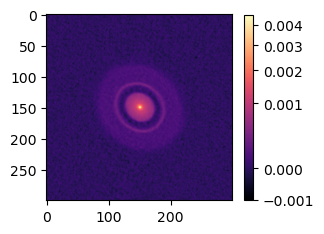

In [357]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(model_1, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [358]:
# Method 2
interp = RegularGridInterpolator(
    (y_, x_), M,
    method="linear", bounds_error=False, fill_value=np.nan
)
pts = np.stack([Ys.ravel(order="C"), Xs.ravel(order="C")], axis=-1)
model_2 = interp(pts).reshape(Ms.shape)

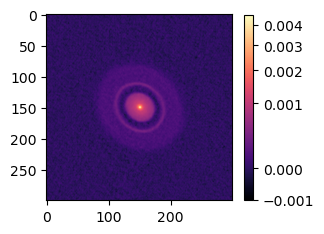

In [359]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(model_2, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [360]:
model_1.shape

(300, 300)

In [361]:
model_2.shape

(300, 300)

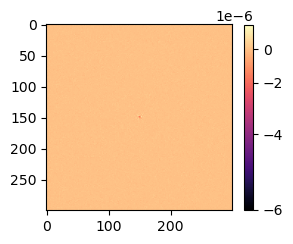

In [362]:
#difference
dif = model_1 - model_2
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(dif, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [368]:
model = model_1

In [369]:
frank_model = M_frank2d

#### convolution with the CLEAN with the restoring beam (to match resolution)

In [370]:
# Beam parameters (major/minor FWHM in degrees and position angle)
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bpa_deg  = float(header.get("BPA", 0.0))

# Projected pixel scales (deg/pix) of the cutout (order (y, x))
dy_deg_pix, dx_deg_pix = proj_plane_pixel_scales(w)[-2], proj_plane_pixel_scales(w)[-1]

# FWHM (arcsec) -> pixels along image axes
bmaj_as = (bmaj_deg * u.deg).to(u.arcsec).value
bmin_as = (bmin_deg * u.deg).to(u.arcsec).value
fwhm_x_pix = bmaj_as / (abs(dx_deg_pix) * 3600.0)   # major axis in pixels along +x if BPA~0
fwhm_y_pix = bmin_as / (abs(dy_deg_pix) * 3600.0)   # minor axis in pixels along +y if BPA~0

# FWHM -> sigma (in pixels)
fwhm_to_sigma = 1.0 / (2.0*np.sqrt(2.0*np.log(2.0)))
sigma_x = fwhm_x_pix * fwhm_to_sigma
sigma_y = fwhm_y_pix * fwhm_to_sigma

# Kernel angle: Gaussian2DKernel expects radians, CCW from image +X;
# BPA is measured from North through East -> image angle = 90 - BPA
theta = np.deg2rad(90.0 - bpa_deg)

# Elliptical Gaussian beam kernel
gk = Gaussian2DKernel(x_stddev=sigma_x, y_stddev=sigma_y, theta=theta, mode='oversample', factor=5)
kernel = gk.array / np.sum(gk.array)  # ensure it sums to 1

# Convolution (preserves units of Jy/sr)
convoluted_model = convolve_fft(frank_model, kernel, allow_huge=True, normalize_kernel=True)

# 3) Convert Jy/sr -> Jy/beam
# Gaussian beam solid angle: omega = 2pi sigma_maj sigma_min, with sigma in radians (note: sigma in rad, not in pixels)
bmaj_rad = (bmaj_deg * u.deg).to(u.rad).value
bmin_rad = (bmin_deg * u.deg).to(u.rad).value
sigma_maj = bmaj_rad * fwhm_to_sigma
sigma_min = bmin_rad * fwhm_to_sigma
Omega_beam_sr = 2.0 * np.pi * sigma_maj * sigma_min  # [sr]

model_conv_Jy_per_beam = convoluted_model * Omega_beam_sr

# 4) COMPARE / RESIDUAL (both in Jy/beam)
residual = model - model_conv_Jy_per_beam

In [371]:
from astropy.stats import sigma_clip

# --- Useful stats ---
# residuals already computed: 'residual' (Jy/beam), same shape as data_c
finite = np.isfinite(residual)
res_vals = residual[finite]

# Robust clipping: 3-sigma, up to 5 iterations, centered on the median
res_clip = sigma_clip(res_vals, sigma=3.0, maxiters=5, cenfunc="median", stdfunc="std")

# RMS of the clipped residual
std = np.nanstd(res_clip)

print(f"RMS residual (clipped): {std:.4g} Jy/beam")
print(f"Residual peak:          {np.nanmax(residual):.4g} Jy/beam")
print(f"Residual min:           {np.nanmin(residual):.4g} Jy/beam")

RMS residual (clipped): 2.41e-05 Jy/beam
Residual peak:          0.002995 Jy/beam
Residual min:           -0.0001993 Jy/beam


In [374]:
np.max(model_conv_Jy_per_beam)

0.0015263010583693817

In [375]:
np.max(model)

0.004521431401219082

In [376]:
np.max(residual)/std

124.30099778701613

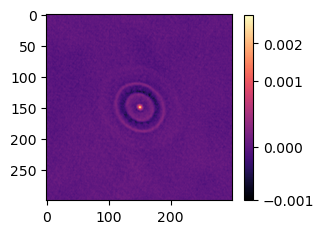

In [372]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(residual, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [ ]:
x, y = frank2d.x_grid, frank2d.y_grid
I = frank2d.intensity_model

In [ ]:
dx, dy = frank2d._FT._dx, frank2d._FT._dy

In [ ]:
domega = dx * dy                      # sr por píxel (campo pequeño)
float(I.sum() * domega)   

In [ ]:
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse

In [ ]:
img_clean = np.squeeze(fits_image[0].data)
header = fits_image[0].header

bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bpa_deg  = float(header.get("BPA", 0.0))

pix_scale = np.round(abs(header['CDELT1']) * 3600, 6)  # arcsec/pixel
bmaj_as = np.radians(bmaj_deg) * 206265  # arcsec
bmin_as = np.radians(bmin_deg) * 206265  # arcsec
bpa_deg = header['BPA']

# tamaño del beam en PIXELES
bmaj_px = bmaj_as / pix_scale
bmin_px = bmin_as / pix_scale

center = len(img_clean)/2.
arcsec_to_px = 1/pix_scale  # px por arcsec

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(
    img_clean, cmap='magma',
    norm=colors.PowerNorm(gamma=0.45)
)

ax.set_xlim(center-2*arcsec_to_px, center+2*arcsec_to_px)
ax.set_ylim(center-2*arcsec_to_px, center+2*arcsec_to_px)

x0 = ax.get_xlim()[0] + 0.15*(ax.get_xlim()[1]-ax.get_xlim()[0])
y0 = ax.get_ylim()[0] + 0.15*(ax.get_ylim()[1]-ax.get_ylim()[0])

beam = Ellipse(
    (x0, y0),
    width=bmaj_px, height=bmin_px, angle=bpa_deg,
    facecolor='white', edgecolor='black', linewidth=0.8,
    zorder=5
)

ax.add_patch(beam)
ticks_x = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]
ticks_y = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]

cbar = fig.colorbar(im, shrink=0.8)
cbar.set_label(r' $I_{\nu}$ [Jy $beam^{-1}$]', rotation=90, labelpad=10)
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(False)
formatter.set_powerlimits((0, 0)) 
cbar.ax.yaxis.set_major_formatter(formatter)


ax.set_xticks(ticks_x); ax.set_yticks(ticks_y)
ax.set_xticklabels([2,1,0,-1,-2]); ax.set_yticklabels([-2,-1,0,1,2])
ax.set_xlabel(r'$\Delta\alpha$ ["]'); ax.set_ylabel(r'$\Delta\delta$ ["]')
ax.set_title(r'CLEAN - $I_{Model}$')

plt.show()

In [ ]:
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

In [ ]:
wcs = WCS(header)

In [ ]:
# Escalas de píxel (magnitudes) [deg/pix_y, deg/pix_x]
deg_per_pix_y, deg_per_pix_x = np.abs(proj_plane_pixel_scales(wcs.celestial))
deg2rad = np.pi/180.0

# Área de píxel (sr), aprox con cos(DEC_ref)
dec_ref_deg = float(header["CRVAL2"])
omega_pix = (deg_per_pix_x*deg2rad) * (deg_per_pix_y*deg2rad) * np.cos(dec_ref_deg*deg2rad)

In [ ]:
x_arcsec, y_arcsec = frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec
extent_convention = [-x_arcsec[0], -x_arcsec[-1], -y_arcsec[-1], -y_arcsec[0]]
model = frank2d.intensity_model

In [ ]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(model, cmap='magma',norm=norm, extent = extent)
plt.colorbar(shrink = 0.8)

In [ ]:
from scipy.interpolate import RegularGridInterpolator
from astropy.wcs import WCS

NY, NX = img_clean.shape

arcsec_per_deg = 3600.0
sx = deg_per_pix_x * arcsec_per_deg
sy = deg_per_pix_y * arcsec_per_deg

# Rejilla CLEAN en arcsec, referida a (CRPIX1,CRPIX2)
crpix1 = float(header["CRPIX1"])  # x (columna), 1-based
crpix2 = float(header["CRPIX2"])  # y (fila), 1-based
jj, ii = np.meshgrid(np.arange(NX), np.arange(NY))  # jj~x, ii~y

x_clean_arcsec = (jj - (crpix1 - 1.0)) * sx
y_clean_arcsec = (ii - (crpix2 - 1.0)) * sy

# Si hay desalineación centro-modelo vs CLEAN:
x0_off_arcsec = dra  # pon aquí tu offset en x si lo conoces
y0_off_arcsec = ddec  # idem en y
xq = x_clean_arcsec - x0_off_arcsec
yq = y_clean_arcsec - y0_off_arcsec

# Interpolador (ejes en orden (y, x))
interp = RegularGridInterpolator(
    (y_arcsec, x_arcsec), model, bounds_error=False, fill_value=0.0, method="linear"
)
model_on_clean = interp(np.column_stack((yq.ravel(), xq.ravel()))).reshape(NY, NX)  # Jy/sr

In [ ]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=4e10)
plt.imshow(model_on_clean, cmap='magma', norm=norm, extent = extent)
plt.colorbar(shrink =0.8)

In [ ]:
from scipy.signal import fftconvolve

import numpy as np, builtins, types, importlib

fwhm_x_pix = float(bmaj_deg) / float(deg_per_pix_x)
fwhm_y_pix = float(bmin_deg) / float(deg_per_pix_y)

# --- FWHM -> sigma (¡asegúrate de tener fwhm_x_pix / fwhm_y_pix definidos!)
sigma_x = (float(fwhm_x_pix)) / (2*np.sqrt(2*np.log(2)))
sigma_y = (float(fwhm_y_pix)) / (2*np.sqrt(2*np.log(2)))

# --- Asegura que sean floats "de verdad"
sigma_x = float(np.asarray(sigma_x).squeeze())
sigma_y = float(np.asarray(sigma_y).squeeze())

# --- Reimporta el módulo math si el nombre 'math' está contaminado
if 'math' in globals() and not isinstance(globals()['math'], types.ModuleType):
    del math
math = importlib.import_module('math')  # módulo limpio

# --- Usa builtins.max y math.ceil explícitos
sigma_max = builtins.max(sigma_x, sigma_y)
half = builtins.int(math.ceil(3.0 * sigma_max))

yy, xx = np.mgrid[-half:half+1, -half:half+1]

theta = float(bpa_deg) * np.pi/180.0  # PA en rad
xrot =  xx*np.cos(theta) + yy*np.sin(theta)
yrot = -xx*np.sin(theta) + yy*np.cos(theta)

beam_kernel = np.exp(-0.5*((xrot/sigma_x)**2 + (yrot/sigma_y)**2))
beam_kernel = beam_kernel / np.max(beam_kernel)  # normaliza a pico=1

In [ ]:
conv_sum = fftconvolve(model_on_clean, beam_kernel, mode="same")  # ≈ Σ I*B
model_jy_per_beam = conv_sum * omega_pix     

In [ ]:
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=0.0016)
plt.imshow(model_jy_per_beam, cmap='magma',norm=norm)
plt.colorbar(shrink=0.8)

In [ ]:
model_jy_per_beam = np.flip(model_jy_per_beam, axis = (0, 1))

In [ ]:
from astropy.stats import sigma_clipped_stats

residual = img_clean - model_jy_per_beam
mean, med, std = sigma_clipped_stats(residual, sigma=3.0, maxiters=5)
print(f"RMS residual (clip): {std:.4g} Jy/beam")
print(f"Pico residual:      {residual.max():.4g} Jy/beam")
print(f"Mín residual:       {residual.min():.4g} Jy/beam")

# Guardar con el header CLEAN (preserva WCS/beam)
#fits.writeto("model_on_clean_jy_per_beam.fits", model_jy_per_beam, header, overwrite=True)
#fits.writeto("residual.fits", residual, header, overwrite=True)

In [ ]:
plt.figure(figsize=(3,3))
plt.imshow(np.log(np.abs(residual)))
plt.colorbar(shrink=0.8)

In [ ]:
# Obtain the radial profiles convolved to a circular beam.
from gofish import imagecube

infile_1mm = fits_name
#2D->1D
cube_1mm = imagecube(infile_1mm)
inc, pa, dra, ddec = data['inc'], data['pa'], data['dra'], data['ddec']
x_1mm,y_1mm,dy_1mm = cube_1mm.radial_profile(inc= data['inc'], PA=data['pa'], x0=data['dra'], y0=data['ddec'])

In [ ]:
plt.figure(figsize=(4, 2))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.title(disk_name + r' 1mm', size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=10)
plt.yscale('log')
plt.ylim(1e-6, 0.5e-2)
plt.xlim(0, rout)
plt.show()

In [ ]:
# let's do a phase shift first.
u_ = frank2d.u_grid
v_ = frank2d.v_grid
vis_ = frank2d.visibility_model
vis = geom.apply_phase_shift(-u_, -v_, vis_)
I_shifted = frank2d.transform(vis).real

In [ ]:
x_arcsec, y_arcsec = frank2d.x_grid*rad_to_arcsec, frank2d.y_grid*rad_to_arcsec
x_arcsec_1d, y_arcsec_1d = frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec
I = frank2d.intensity_model

In [ ]:
intensity_model = I_shifted

In [ ]:
x_arcsec_d, y_arcsec_d = geom.deproject_xy(frank2d.x_grid*rad_to_arcsec, frank2d.y_grid*rad_to_arcsec)
x_arcsec_1d_d, y_arcsec_1d_d = geom.deproject_xy( frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec)

In [ ]:
bins = 300
r = np.unique(np.hypot(x_arcsec_1d_d, y_arcsec_1d_d))
r = np.linspace(r.min(), r.max(), bins)
r_edges = Plot_.edges(r)

In [ ]:
r_model_1d, int_model_1d = Plot_.get_profile(x_arcsec_d, y_arcsec_d, intensity_model, r_edges )

In [ ]:
int_model_1d = np.nan_to_num(int_model_1d, nan=0)/ np.cos(inc*deg_to_rad)

In [ ]:
from frank.utilities import convolve_profile

header = fits_image[0].header

bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam_1mm = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
area_1mm = clean_beam_1mm['bmaj']*clean_beam_1mm['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

model_convolved = convolve_profile(r_model_1d, int_model_1d, inc, pa, clean_beam_1mm)*area_1mm

In [ ]:
plt.figure(figsize=(7, 3))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.plot(r_model_1d, model_convolved, "blue", ls= '--', label=r'frankenstein2D')
plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.ylim(1e-6, 3e-3)
plt.xlim(0,1.2)
plt.show()

In [ ]:
alpha = 1.2
wsmooth = 1e-1

In [ ]:
sol = frank2d.frank1d(alpha = alpha, w_smooth = wsmooth)

In [ ]:
plt.plot(r_model_1d, int_model_1d/1e10, label = "frank2d")
plt.plot(sol.r, sol.mean/1e10,label ='frank1d')
plt.xlabel('Radius ["]', size = 10)
plt.ylabel(r'Brightness profile [$10^{10}$ Jy sr$^{-1}$]', size = 10)
plt.xlim(0, rout)
plt.ylim(1e-2, 1e2)
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
convolved_1mm_frank1d = convolve_profile(sol.r, sol.mean, inc, pa, clean_beam_1mm)*area_1mm

In [ ]:
plt.figure(figsize=(7, 3))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.plot(sol.r, convolved_1mm_frank1d, "red", label=r'frankenstein1D')
plt.plot(r_model_1d, model_convolved, "blue", ls= '--', label=r'frankenstein2D')
plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.ylim(1e-6, 1e-2)
plt.xlim(0,1.2)
plt.show()

In [ ]:
Dchol = scipy.linalg.cho_factor(Dinv) ## HACERLO CON BICGSTAB!!! INSTEAD
size = N*N
num_fields = 1

In [ ]:
b = np.eye(size*num_fields)
cov = scipy.linalg.cho_solve(Dchol, b)